# **Business scenario**

A company ran two digital marketing campaigns in August 2019:

*  **Control Campaign**
*  **Test Campaign**

This goal is to evaluate whether the test marketing campaign performed differently from the control campaign in terms of purchase conversion efficiency.

The comparison is based on total purchases and total website clicks for each campaign.

### **Main business question**
Did the test marketing campaign perform differently from the control campaign in terms of purchase conversion efficiency?

# **What to test**
### **Primary Metric**
Because this dataset is aggregated by day, your most defensible primary metric is:

**Purchase conversion rate from website clicks**

**Purchase Conversion Rate** =
Website Clicks/
Purchases

This is the cleanest “conversion” definition for this dataset.

### **secondary metrics**

* CTR = Website Clicks / Impressions
* Add-to-cart rate = Added to Cart / Website Clicks
* Cost per purchase = Amount Spent / Purchases

# **Initial Hypotheses:**
### Null Hypothesis (H₀)
p control =p test
	​


The purchase conversion rate of the test campaign is equal to the purchase conversion rate of the control campaign.

There is no statistically significant difference between campaigns.

### Alternative Hypothesis (H₁)
p
control
!= p
test

The purchase conversion rate of the test campaign is different from the purchase conversion rate of the control campaign.

There is a statistically significant difference in conversion performance between campaigns.

In [2]:
pip install pandas numpy scipy statsmodels pingouin matplotlib jupyter

  Using cached pingouin-0.6.1-py3-none-any.whl.metadata (19 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.8 MB/s eta 0:00:00


Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

Mount Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the cleaned data

In [6]:
df = pd.read_csv("/content/drive/MyDrive/marketing-ab-testing/data/marketing_ab_clean.csv", parse_dates=["date"])
df.head()

,campaign_name,date,amount_spent,impressions,reach,website_clicks,searches_received,content_viewed,added_to_cart,purchases,group,ctr,conversion_rate,add_to_cart_rate,purchase_per_impression,cost_per_purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control,0.084835,0.088084,0.259265,0.007473,3.689320
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control,0.067003,0.063009,0.150308,0.004222,3.438356
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control,0.049411,0.057160,0.174247,0.002824,6.298387
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control,0.042057,0.110930,0.385971,0.004665,5.705882
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control,0.036928,0.189672,0.194638,0.007004,4.035340


Initial checks

In [7]:
df.info()
df.isnull().sum()
df["group"].value_counts()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   campaign_name            59 non-null     object        
 1   date                     59 non-null     datetime64[ns]
 2   amount_spent             59 non-null     int64         
 3   impressions              59 non-null     float64       
 4   reach                    59 non-null     float64       
 5   website_clicks           59 non-null     float64       
 6   searches_received        59 non-null     float64       
 7   content_viewed           59 non-null     float64       
 8   added_to_cart            59 non-null     float64       
 9   purchases                59 non-null     float64       
 10  group                    59 non-null     object        
 11  ctr                      59 non-null     float64       
 12  conversion_rate          59 non-null  

,date,amount_spent,impressions,reach,website_clicks,searches_received,content_viewed,added_to_cart,purchases,ctr,conversion_rate,add_to_cart_rate,purchase_per_impression,cost_per_purchase
count,59,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2019-08-15 16:16:16.271186432,2435.762712,91775.881356,70868.644068,5682.593220,2321.813559,1900.169492,1087.220339,522.000000,0.077127,0.103352,0.217041,0.006742,5.483144
min,2019-08-01 00:00:00,1757.000000,22521.000000,10598.000000,2277.000000,1001.000000,848.000000,278.000000,222.000000,0.018575,0.030088,0.045696,0.001831,2.253750
25%,2019-08-08 12:00:00,2113.500000,68853.500000,43230.000000,4227.500000,1962.500000,1249.000000,848.500000,340.000000,0.042786,0.063322,0.130284,0.004125,3.494772
50%,2019-08-16 00:00:00,2421.000000,95843.000000,76219.000000,5691.000000,2390.000000,1975.000000,1075.000000,501.000000,0.063799,0.088084,0.183800,0.005780,4.789668
75%,2019-08-23 00:00:00,2743.000000,117315.000000,95490.500000,7218.500000,2778.500000,2424.000000,1386.500000,693.000000,0.084525,0.130510,0.272937,0.007894,7.520500
max,2019-08-30 00:00:00,3112.000000,145248.000000,127852.000000,8264.000000,4891.000000,4219.000000,1913.000000,890.000000,0.338218,0.322354,0.715415,0.022734,12.702041
std,NaN,376.358795,32465.070636,31023.653515,1754.777559,669.040576,687.263844,430.205246,196.973917,0.056291,0.058098,0.133400,0.004342,2.503649


Compare campaign totals

In [8]:
summary = df.groupby("group").agg(
    days=("date", "count"),
    total_spend=("amount_spent", "sum"),
    total_impressions=("impressions", "sum"),
    total_clicks=("website_clicks", "sum"),
    total_purchases=("purchases", "sum"),
    avg_daily_conversion_rate=("conversion_rate", "mean"),
    avg_daily_ctr=("ctr", "mean"),
    avg_cost_per_purchase=("cost_per_purchase", "mean")
).reset_index()

summary["overall_conversion_rate"] = summary["total_purchases"] / summary["total_clicks"]
summary["overall_ctr"] = summary["total_clicks"] / summary["total_impressions"]

summary

,group,days,total_spend,total_impressions,total_clicks,total_purchases,avg_daily_conversion_rate,avg_daily_ctr,avg_cost_per_purchase,overall_conversion_rate,overall_ctr
0,control,29,66818,3177233.0,154303.0,15161.0,0.114772,0.050959,5.052339,0.098255,0.048565
1,test,30,76892,2237544.0,180970.0,15637.0,0.092312,0.102423,5.899589,0.086407,0.080879


Visualize daily trends

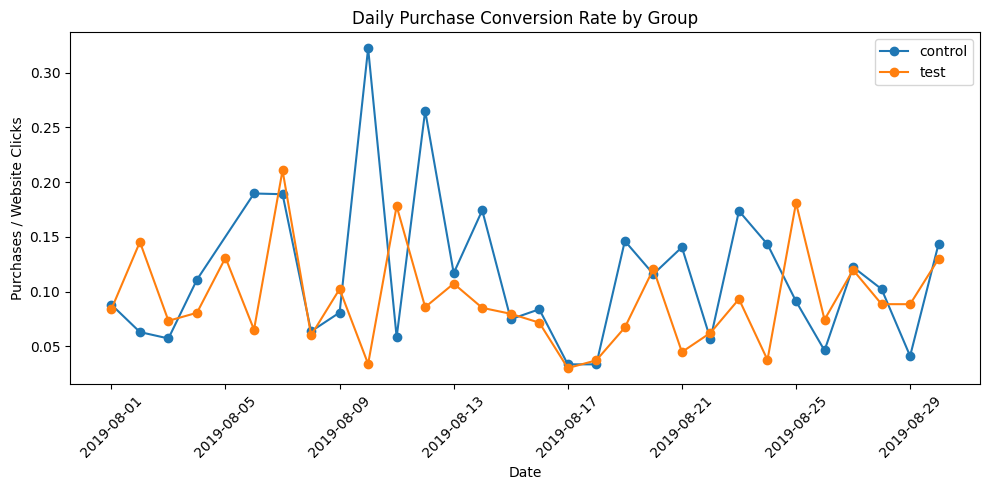

In [9]:
plt.figure(figsize=(10, 5))
for grp in df["group"].unique():
    temp = df[df["group"] == grp]
    plt.plot(temp["date"], temp["conversion_rate"], marker="o", label=grp)

plt.title("Daily Purchase Conversion Rate by Group")
plt.xlabel("Date")
plt.ylabel("Purchases / Website Clicks")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

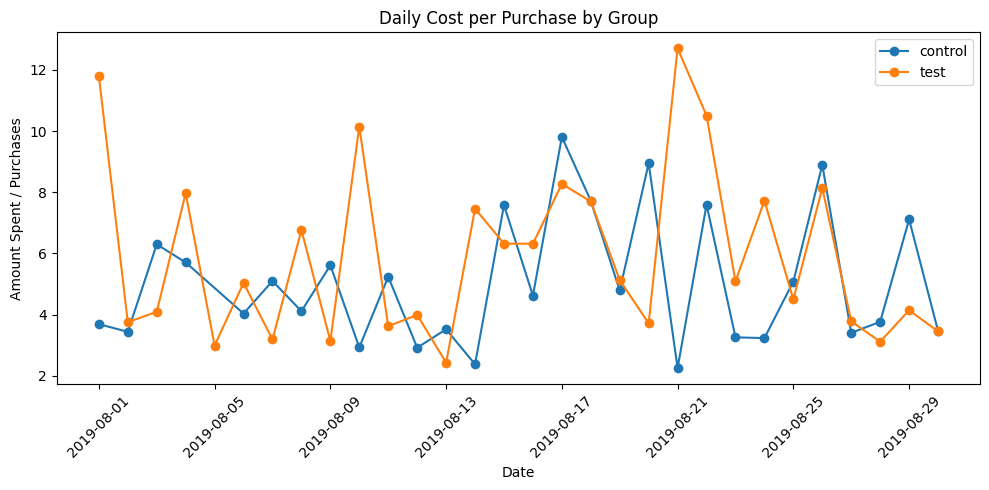

In [10]:
plt.figure(figsize=(10, 5))
for grp in df["group"].unique():
    temp = df[df["group"] == grp]
    plt.plot(temp["date"], temp["cost_per_purchase"], marker="o", label=grp)

plt.title("Daily Cost per Purchase by Group")
plt.xlabel("Date")
plt.ylabel("Amount Spent / Purchases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Primary A/B test**

Because purchases and clicks are count data, use a two-proportion z-test on total conversions.

## **Run the main hypothesis test**

In [11]:
group_totals = df.groupby("group").agg(
    clicks=("website_clicks", "sum"),
    purchases=("purchases", "sum")
).reset_index()

group_totals

,group,clicks,purchases
0,control,154303.0,15161.0
1,test,180970.0,15637.0


### **2 proportion z-test**

In [12]:
control_clicks = group_totals.loc[group_totals["group"] == "control", "clicks"].iloc[0]
test_clicks = group_totals.loc[group_totals["group"] == "test", "clicks"].iloc[0]

control_purchases = group_totals.loc[group_totals["group"] == "control", "purchases"].iloc[0]
test_purchases = group_totals.loc[group_totals["group"] == "test", "purchases"].iloc[0]

counts = np.array([control_purchases, test_purchases])
nobs = np.array([control_clicks, test_clicks])

z_stat, p_value = proportions_ztest(count=counts, nobs=nobs, alternative="two-sided")

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 11.8386745814439
P-value: 2.4631475628426749e-32


The **two-proportion z-test** was conducted to evaluate whether there was a statistically significant difference in purchase conversion rates between the control and test marketing campaigns.

The **control** campaign recorded **154,303** **clicks** and **15,161 purchases**, while the **test** campaign recorded **180,970 clicks** and **15,637 purchases**.

The calculated test statistics were:

Z-statistic: 11.84
P-value: 2.46 × 10⁻³²

Since the p-value is **significantly less** than the significance level of 0.05, we **reject the null hypothesis**.

This indicates that there is a **statistically significant difference** in purchase conversion rates between the two campaigns.

However, the direction of the difference shows that the **test campaign had a lower conversion rate compared to the control campaign**.

## **Compute lift**

In [13]:
control_cr = control_purchases / control_clicks
test_cr = test_purchases / test_clicks

absolute_lift = test_cr - control_cr
relative_lift = absolute_lift / control_cr

print("Control conversion rate:", round(control_cr, 4))
print("Test conversion rate:", round(test_cr, 4))
print("Absolute lift:", round(absolute_lift, 4))
print("Relative lift (%):", round(relative_lift * 100, 2))

Control conversion rate: 0.0983
Test conversion rate: 0.0864
Absolute lift: -0.0118
Relative lift (%): -12.06


Although the test campaign generated more traffic and clicks, it converted visitors into customers less efficiently than the control campaign.

## **Confidence interval for difference in proportions**

In [14]:
low, high = confint_proportions_2indep(
    count1=test_purchases,
    nobs1=test_clicks,
    count2=control_purchases,
    nobs2=control_clicks,
    method="wald"
)

print("95% CI for (test - control):", (low, high))

95% CI for (test - control): (np.float64(-0.013818282416173123), np.float64(-0.009878009272920306))


A 95% confidence interval was calculated to estimate the range of plausible values for the difference in purchase conversion rates between the test and control campaigns.

The computed confidence interval for the difference in conversion rates (test − control) was:

Lower bound: −0.0138

Upper bound: −0.0099

This interval represents the estimated difference in conversion rates between the two campaigns, expressed in proportion terms.

The confidence interval is entirely **negative**, meaning that the conversion rate of the test campaign is **consistently lower** than that of the control campaign.

Specifically, we are 95% confident that the test campaign conversion rate is between:
0.99% and 1.38% lower
than the control campaign conversion rate.

Because the confidence interval does not include zero, the difference in conversion rates is statistically significant at the 5% significance level. This finding supports the conclusion from the two-proportion z-test.

# **Daily Campaign Performance**

**Check assumptions for daily conversion rate**

In [15]:
control_daily = df.loc[df["group"] == "control", "conversion_rate"]
test_daily = df.loc[df["group"] == "test", "conversion_rate"]

print("Shapiro control:", shapiro(control_daily))
print("Shapiro test:", shapiro(test_daily))
print("Levene:", levene(control_daily, test_daily))

Shapiro control: ShapiroResult(statistic=np.float64(0.8946046791264094), pvalue=np.float64(0.00729366705052213))
Shapiro test: ShapiroResult(statistic=np.float64(0.9254688343258307), pvalue=np.float64(0.03726829960369907))
Levene: LeveneResult(statistic=np.float64(3.4325842446951373), pvalue=np.float64(0.06910165314376589))


**Since assumptions are not okay, use Mann-Whitney**

In [17]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    control_daily,
    test_daily,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U statistic: 503.0
P-value: 0.30610346625699913


Before comparing daily conversion rates between campaigns, statistical assumptions were evaluated to determine the appropriate test.

**Normality Test (Shapiro–Wilk)**

The Shapiro–Wilk test was conducted to assess whether daily conversion rates followed a **normal** distribution.

Results:

* Control group p-value: 0.0073
* Test group p-value: 0.0373

Since both p-values are less than the significance level of 0.05, the normality assumption is violated for both groups. This indicates that **daily conversion rates are not normally distributed.**

**Equal Variance Test (Levene)**

The Levene test was used to evaluate whether the variance of daily conversion rates was similar between the two campaigns.

Result:

Levene p-value: 0.0691

Since the p-value is greater than 0.05, we **fail to reject the null hypothesis of equal variances**. This suggests that the variability of daily conversion rates is **similar** between the campaigns.

Statistical Test Selection

Because the **normality assumption was violated**, a **nonparametric Mann–Whitney U test was selected** instead of a t-test to compare daily conversion rate distributions between the control and test campaigns.

The **Mann–Whitney U test** was performed to determine whether there was a statistically significant difference in daily conversion rate distributions between the campaigns.

Results:

U statistic: 503.0
P-value: 0.306

Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

# **Secondary Metrics**

In [18]:
import numpy as np

# CTR
df["ctr"] = np.where(
    df["impressions"] > 0,
    df["website_clicks"] / df["impressions"],
    np.nan
)

# Add-to-cart rate
df["add_to_cart_rate"] = np.where(
    df["website_clicks"] > 0,
    df["added_to_cart"] / df["website_clicks"],
    np.nan
)

# Purchase per impression
df["purchase_per_impression"] = np.where(
    df["impressions"] > 0,
    df["purchases"] / df["impressions"],
    np.nan
)

# Cost per purchase
df["cost_per_purchase"] = np.where(
    df["purchases"] > 0,
    df["amount_spent"] / df["purchases"],
    np.nan
)

df.head()

,campaign_name,date,amount_spent,impressions,reach,website_clicks,searches_received,content_viewed,added_to_cart,purchases,group,ctr,conversion_rate,add_to_cart_rate,purchase_per_impression,cost_per_purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control,0.084835,0.088084,0.259265,0.007473,3.689320
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control,0.067003,0.063009,0.150308,0.004222,3.438356
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control,0.049411,0.057160,0.174247,0.002824,6.298387
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control,0.042057,0.110930,0.385971,0.004665,5.705882
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control,0.036928,0.189672,0.194638,0.007004,4.035340


Aggregate Secondary Metrics by Campaign

In [19]:
secondary_summary = df.groupby("group").agg(
    avg_ctr=("ctr", "mean"),
    avg_add_to_cart_rate=("add_to_cart_rate", "mean"),
    avg_purchase_per_impression=("purchase_per_impression", "mean"),
    avg_cost_per_purchase=("cost_per_purchase", "mean")
).reset_index()

secondary_summary

,group,avg_ctr,avg_add_to_cart_rate,avg_purchase_per_impression,avg_cost_per_purchase
0,control,0.050959,0.278209,0.005001,5.052339
1,test,0.102423,0.157912,0.008425,5.899589


Compute Weighted (Overall) Metrics

In [20]:
overall_secondary = df.groupby("group").agg(
    total_impressions=("impressions", "sum"),
    total_clicks=("website_clicks", "sum"),
    total_added_to_cart=("added_to_cart", "sum"),
    total_purchases=("purchases", "sum"),
    total_spend=("amount_spent", "sum")
).reset_index()

overall_secondary["ctr"] = (
    overall_secondary["total_clicks"]
    / overall_secondary["total_impressions"]
)

overall_secondary["add_to_cart_rate"] = (
    overall_secondary["total_added_to_cart"]
    / overall_secondary["total_clicks"]
)

overall_secondary["purchase_per_impression"] = (
    overall_secondary["total_purchases"]
    / overall_secondary["total_impressions"]
)

overall_secondary["cost_per_purchase"] = (
    overall_secondary["total_spend"]
    / overall_secondary["total_purchases"]
)

overall_secondary

,group,total_impressions,total_clicks,total_added_to_cart,total_purchases,total_spend,ctr,add_to_cart_rate,purchase_per_impression,cost_per_purchase
0,control,3177233.0,154303.0,37700.0,15161.0,66818,0.048565,0.244324,0.004772,4.407229
1,test,2237544.0,180970.0,26446.0,15637.0,76892,0.080879,0.146135,0.006988,4.917312


## Statistical Testing for Secondary Metrics
Since your normality assumption failed earlier, use Mann–Whitney.

### Test CTR

In [21]:
from scipy.stats import mannwhitneyu

control_ctr = df.loc[
    df["group"] == "control",
    "ctr"
]

test_ctr = df.loc[
    df["group"] == "test",
    "ctr"
]

stat, p_value = mannwhitneyu(
    control_ctr,
    test_ctr,
    alternative="two-sided"
)

print("CTR Mann-Whitney p-value:", p_value)

CTR Mann-Whitney p-value: 0.00025063172993413605


To further evaluate campaign performance, a Mann–Whitney U test was conducted to compare the distribution of daily click-through rates (CTR) between the control and test campaigns.

CTR=
Impressions /
Website Clicks
	​

This metric measures user engagement and the effectiveness of the marketing campaign in generating website visits from impressions.

Since the p-value is less than the significance level of 0.05, we reject the null hypothesis.

The test campaign generated a significantly different level of user engagement compared to the control campaign, as measured by CTR. This suggests that the campaigns attracted user attention differently, which may have influenced downstream conversion performance.

### Test Cost per Purchase

In [22]:
control_cpp = df.loc[
    df["group"] == "control",
    "cost_per_purchase"
]

test_cpp = df.loc[
    df["group"] == "test",
    "cost_per_purchase"
]

stat, p_value = mannwhitneyu(
    control_cpp,
    test_cpp,
    alternative="two-sided"
)

print("Cost per Purchase Mann-Whitney p-value:", p_value)

Cost per Purchase Mann-Whitney p-value: 0.27166245232517694


To evaluate the financial efficiency of each campaign, a Mann–Whitney U test was conducted to compare the distribution of daily cost per purchase between the control and test campaigns.

Cost per Purchase=
Number of Purchases /
Amount Spent​

This metric measures how much the company spends to acquire each customer and is a key indicator of marketing efficiency.
Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.
Although the average cost per purchase may differ numerically between campaigns, the statistical test suggests that the observed variation in daily marketing cost efficiency is within the range of normal variability.

In other words, the difference in cost per purchase is not large enough to conclude that one campaign is consistently more expensive than the other on a day-to-day basis.

### Add-to-Cart Rate

In [23]:
from scipy.stats import mannwhitneyu

control_atc = df.loc[
    df["group"] == "control",
    "add_to_cart_rate"
]

test_atc = df.loc[
    df["group"] == "test",
    "add_to_cart_rate"
]

stat, p_value = mannwhitneyu(
    control_atc,
    test_atc,
    alternative="two-sided"
)

print("Add-to-Cart Rate Mann-Whitney p-value:", p_value)

Add-to-Cart Rate Mann-Whitney p-value: 0.00037728989820598273


To further evaluate user behavior within the marketing funnel, a Mann–Whitney U test was conducted to compare the distribution of daily add-to-cart rates between the control and test campaigns.

Add-to-Cart Rate=
Website Clicks /
Added to Cart

This metric measures customer purchase intent and reflects how effectively website visitors progress from browsing to considering a purchase.

Since the p-value is less than the significance level of 0.05, we reject the null hypothesis.

The significant difference in add-to-cart rate suggests that users interacted with products differently across campaigns. This indicates that customer purchase intent behavior varied between the control and test campaigns.

Because this metric sits in the middle of the customer journey, the result helps explain where the conversion performance difference originated.

# **Business interpretation**

The A/B testing analysis evaluated the performance of the test marketing campaign relative to the control campaign across multiple stages of the customer journey, including user engagement, purchase intent, conversion efficiency, and cost effectiveness.

* The primary hypothesis test using a **two-proportion z-test** showed a **statistically significant difference** in **purchase conversion rates** between the campaigns.
* The **confidence interval** for the difference in conversion rates was **entirely negative**, indicating that the **test** campaign consistently **converted visitors at a lower rate** than the **control** campaign.

Secondary metric analysis provided additional insight into the drivers of this performance difference.
* The **click-through rate (CTR)** and **add-to-cart rate** both showed **statistically significant differences** between campaigns, indicating that user engagement and purchase intent behavior varied meaningfully across the marketing funnel.
These results suggest that customers interacted differently with the test campaign compared to the control campaign.

* In contrast, the **cost per purchase analysis** showed **no statistically significant difference** between campaigns. This indicates that marketing spend efficiency remained relatively stable, and the observed performance gap was not driven by changes in cost behavior.

Additionally, the analysis of **daily conversion rate **distributions showed **no statistically significant difference in day-to-day variability** between campaigns. This suggests that the performance difference was consistent across the testing period rather than caused by isolated fluctuations or outlier days.

# **Conclusion**

Taken together, the results indicate that the **test campaign underperformed relative to the control campaign** in terms of **conversion efficiency.** The difference in performance is statistically significant, operationally meaningful, and supported by consistent behavioral differences across the customer funnel.

The evidence suggests that the issue is most likely related to **user interaction or customer experience** rather than marketing spend efficiency.


# **Recommendation**

Based on the statistical and operational findings, the company should retain the control campaign as the current production strategy. The test campaign should not be deployed in its current form. Instead, further investigation should be conducted to identify specific factors affecting user engagement and purchase behavior, such as messaging, targeting, or user interface changes.

Future experiments should focus on optimizing the stages of the customer journey where engagement and purchase intent differ most significantly.
